# 01 - EDA dan Validasi Data CoreTax

Notebook ini memuat data mentah, memvalidasi kolom dan kualitas data, membuat label proxy dari rating, lalu menampilkan visualisasi distribusi rating, sentimen, dan panjang review.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "data" / "raw").is_dir())
RAW_PATH = ROOT / "data" / "raw" / "coretax_reviews.csv"
LABELS = ["negatif", "netral", "positif"]

# Load dan validasi data mentah.
df = pd.read_csv(RAW_PATH)
print(f"Ukuran data mentah: {df.shape}")
print("Kolom:", df.columns.tolist())
print("Missing values:\n", df.isna().sum())

required = {"review_text", "rating"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Kolom wajib tidak ditemukan: {sorted(missing)}")

df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
print("Rating di luar rentang 1-5:", (~df["rating"].between(1, 5)).sum())
print("Duplikat review:", df.duplicated(subset=["review_text"]).sum())
print("Review kosong:", df["review_text"].fillna("").astype(str).str.strip().eq("").sum())
print("Rentang tanggal:", df["date"].min(), "sampai", df["date"].max())

# Bersihkan baris invalid dan buat proxy label rating.
df = df.dropna(subset=["review_text", "rating"]).copy()
df = df[df["rating"].between(1, 5)]
df["review_text"] = df["review_text"].astype(str).str.strip()
df = df[df["review_text"].ne("")].drop_duplicates(subset=["review_text"]).copy()
df["sentiment"] = df["rating"].map(lambda rating: "negatif" if rating <= 2 else ("netral" if rating == 3 else "positif"))

# Ukuran kelas dan proporsi.
distribution = df["sentiment"].value_counts().reindex(LABELS, fill_value=0).to_frame("jumlah")
distribution["persentase"] = distribution["jumlah"] / len(df) * 100
distribution

Ukuran data mentah: (8711, 6)
Kolom: ['user_name', 'rating', 'date', 'review_text', 'likes', 'app_version']
Missing values:
 user_name         0
rating            0
date              0
review_text       0
likes             0
app_version    2142
dtype: int64
Rating di luar rentang 1-5: 0
Duplikat review: 821
Review kosong: 0
Rentang tanggal: 2021-06-04 18:42:28 sampai 2026-09-02 13:36:29


,jumlah,persentase
sentiment,,
negatif,6748,85.525982
netral,200,2.534854
positif,942,11.939163


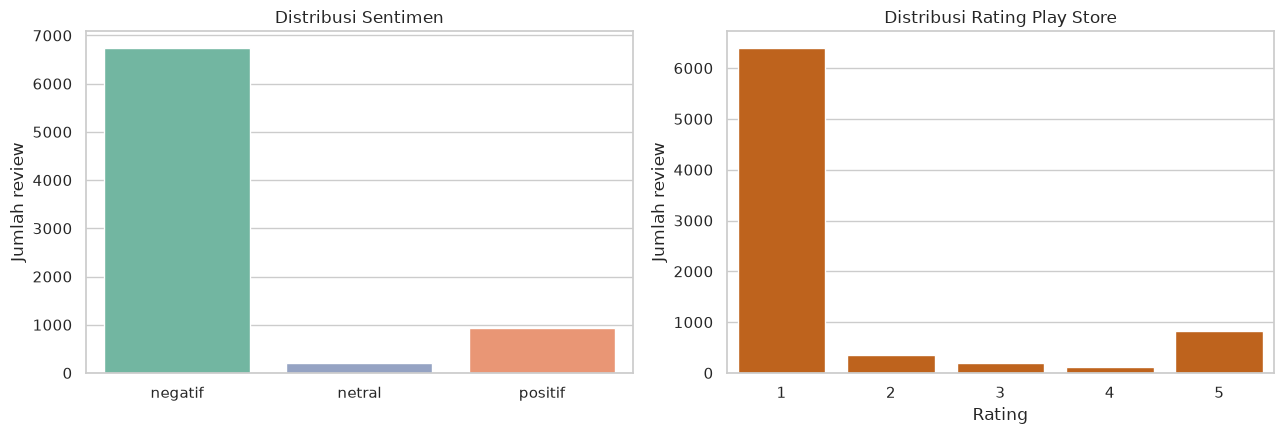

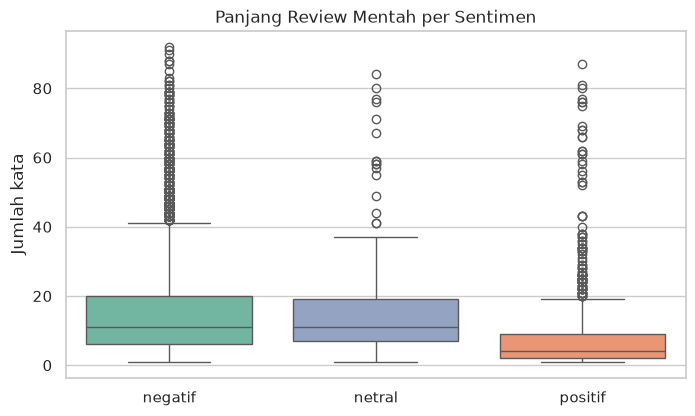

In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(data=df, x="sentiment", order=LABELS, hue="sentiment", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Distribusi Sentimen")
axes[0].set_xlabel("")
axes[0].set_ylabel("Jumlah review")
sns.countplot(data=df, x="rating", order=[1, 2, 3, 4, 5], color="#d95f02", ax=axes[1])
axes[1].set_title("Distribusi Rating Play Store")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Jumlah review")
plt.tight_layout()
plt.show()

# Panjang teks mentah sebagai konteks eksplorasi.
df["raw_text_length"] = df["review_text"].str.split().str.len()
plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x="sentiment", y="raw_text_length", order=LABELS, hue="sentiment", palette="Set2", legend=False)
plt.title("Panjang Review Mentah per Sentimen")
plt.xlabel("")
plt.ylabel("Jumlah kata")
plt.show()